# Classificação de Expressões Faciais por Sinais EMG

**Autoria:** Heitor Teixeira

O objetivo deste projeto é implementar e comparar diferentes algoritmos de classificação aplicados a sinais de eletromiografia (EMG) para reconhecimento de expressões faciais. O conjunto de dados contém 50.000 amostras com duas features (x1 e x2) e cinco classes: *neutro*, *sorriso*, *aberto*, *surpreso* e *grumpy*.

# 1. Configuração

## 1.1. Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

## 1.2. Funções Auxiliares

In [2]:
def summary_stats(acuracias, label=''):
    acuracias = np.array(acuracias)
    scale = 100 if acuracias.max() <= 1.0 else 1.0
    return pd.DataFrame({
        'Modelo': [label],
        'Média (%)': [round(np.mean(acuracias) * scale, 2)],
        'Desvio Padrão (%)': [round(np.std(acuracias) * scale, 2)],
        'Máximo (%)': [round(np.max(acuracias) * scale, 2)],
        'Mínimo (%)': [round(np.min(acuracias) * scale, 2)],
    })


def plot_confusion_matrix(cm, title='Matriz de Confusão', labels=None):
    cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='inferno',
                vmin=0, vmax=1, xticklabels=labels, yticklabels=labels)
    plt.xlabel('Previsão', fontsize=14)
    plt.ylabel('Real', fontsize=14)
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show()


def normal_pdf(x, media, std):
    return (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - media) / std) ** 2)

## 1.3. Carregamento dos Dados

In [3]:
db_caracteristicas = pd.read_csv('EMG_DATASET/EMG.csv', header=None, names=['x1', 'x2'])
db_rotulos = pd.read_csv('EMG_DATASET/Rotulos.csv', header=None, names=['neutro', 'sorriso', 'aberto', 'surpreso', 'grumpy'])
dados = pd.concat([db_caracteristicas, db_rotulos], axis=1)

dados['rotulo'] = dados.loc[:, ['neutro', 'sorriso', 'aberto', 'surpreso', 'grumpy']].idxmax(axis=1)

inputs = dados.loc[:, ['x1', 'x2']].values
outputs = dados.loc[:, ['neutro', 'sorriso', 'aberto', 'surpreso', 'grumpy']].values

cores = ['red', 'blue', 'green', 'purple', 'orange']
rotulos = ['neutro', 'sorriso', 'aberto', 'surpreso', 'grumpy']

# 2. Análise Exploratória de Dados

## 2.1. Distribuição das Classes

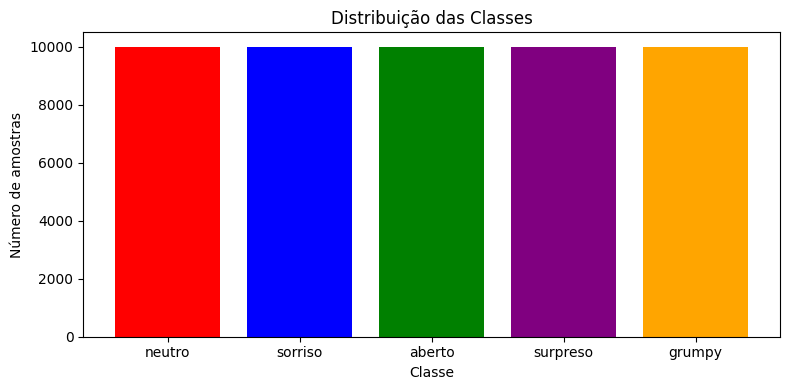

,Amostras
rotulo,
neutro,10000
sorriso,10000
aberto,10000
surpreso,10000
grumpy,10000


In [4]:
contagem_classes = dados['rotulo'].value_counts().reindex(rotulos)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(contagem_classes.index, contagem_classes.values, color=cores)
ax.set_title('Distribuição das Classes')
ax.set_xlabel('Classe')
ax.set_ylabel('Número de amostras')
plt.tight_layout()
plt.show()

contagem_classes.to_frame('Amostras')

## 2.2. Estatísticas Descritivas por Feature

In [5]:
stats = pd.DataFrame({
    'Feature': ['x1', 'x2'],
    'Média': [dados['x1'].mean(), dados['x2'].mean()],
    'Desvio Padrão': [dados['x1'].std(), dados['x2'].std()],
    'Mínimo': [dados['x1'].min(), dados['x2'].min()],
    'Máximo': [dados['x1'].max(), dados['x2'].max()],
    'Correlação (x1, x2)': [dados[['x1', 'x2']].corr().iloc[0, 1], '—'],
}).set_index('Feature')

display(
    stats.style
    .format({'Média': '{:.4f}', 'Desvio Padrão': '{:.4f}', 'Mínimo': '{:.4f}', 'Máximo': '{:.4f}'})
    .set_caption('Tabela 2.1: Estatísticas Descritivas das Features')
)

,Média,Desvio Padrão,Mínimo,Máximo,"Correlação (x1, x2)"
Feature,,,,,
x1,669.9538,753.2523,0.0000,3732.0000,-0.129704
x2,1216.7039,1457.8864,0.0000,4009.0000,—


## 2.3. Scatter Plot

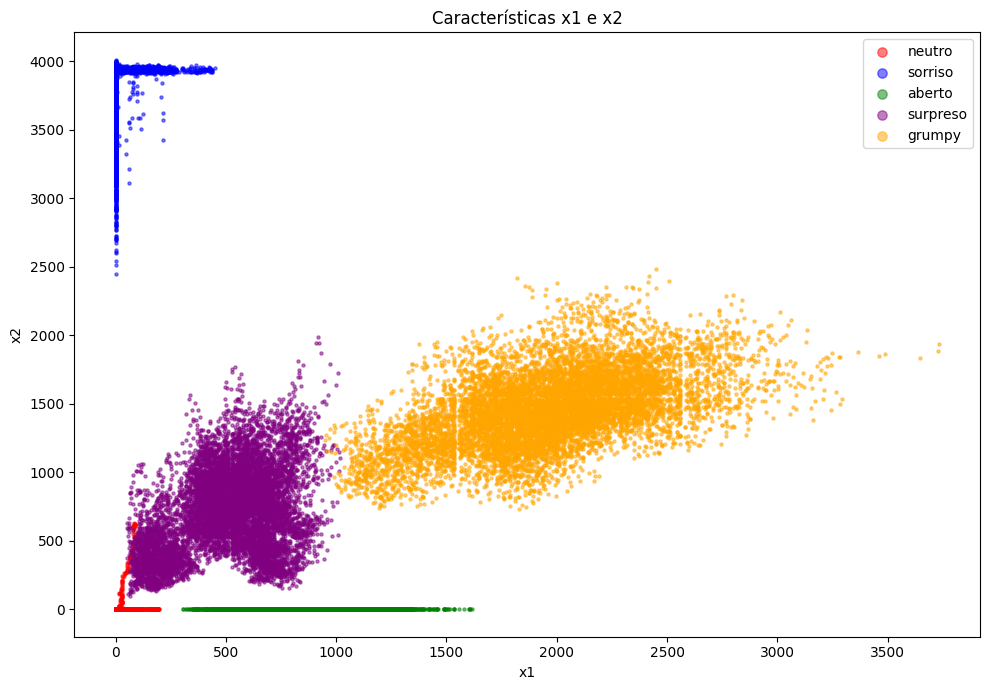

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
for i, rotulo in enumerate(rotulos):
    mask = dados['rotulo'] == rotulo
    ax.scatter(dados.loc[mask, 'x1'], dados.loc[mask, 'x2'],
               c=cores[i], label=rotulo, alpha=0.5, s=5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Características x1 e x2')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

## 2.4. Box Plot por Classe

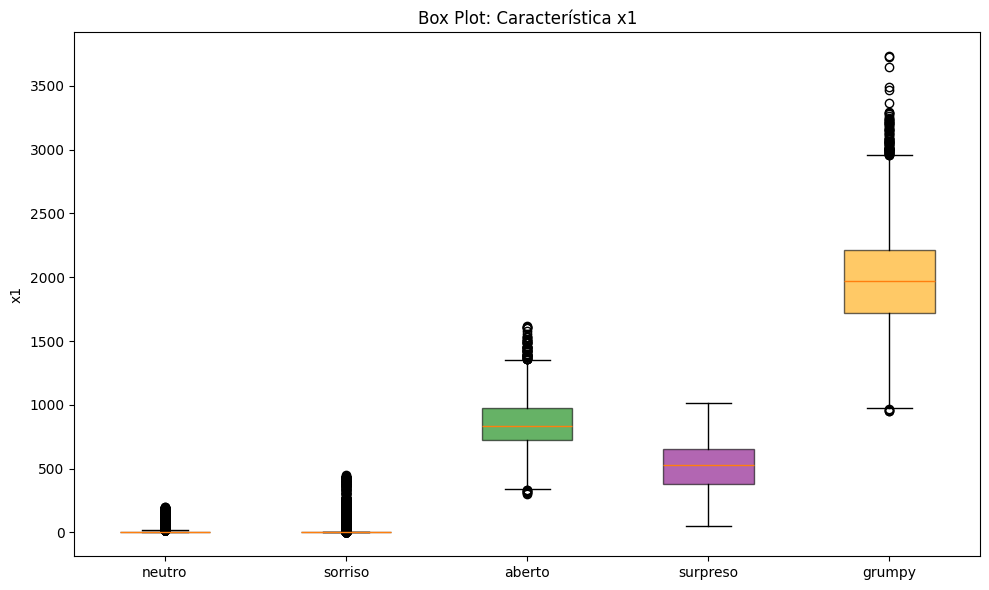

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
data_boxplot = [dados[dados['rotulo'] == r]['x1'].values for r in rotulos]
bp = ax.boxplot(data_boxplot, tick_labels=rotulos, patch_artist=True)
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.6)
ax.set_title('Box Plot: Característica x1')
ax.set_ylabel('x1')
plt.tight_layout()
plt.show()

## 2.5. Estatísticas dos Quartis por Classe

In [8]:
rows = []
for rotulo_nome, grupo in dados.groupby('rotulo'):
    q1 = grupo['x1'].quantile(0.25)
    q2 = grupo['x1'].quantile(0.50)
    q3 = grupo['x1'].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = grupo[(grupo['x1'] < lim_inf) | (grupo['x1'] > lim_sup)].shape[0]
    rows.append({
        'Classe': rotulo_nome,
        'Lim. Inferior': lim_inf,
        'Q1': q1,
        'Q2 (Mediana)': q2,
        'Q3': q3,
        'Lim. Superior': lim_sup,
        'Outliers': outliers,
    })

display(
    pd.DataFrame(rows).set_index('Classe').style
    .format({'Lim. Inferior': '{:.4f}', 'Q1': '{:.4f}', 'Q2 (Mediana)': '{:.4f}',
             'Q3': '{:.4f}', 'Lim. Superior': '{:.4f}', 'Outliers': '{:.0f}'})
    .set_caption('Tabela 2.2: Estatísticas dos Quartis de x1 por Classe')
)

,Lim. Inferior,Q1,Q2 (Mediana),Q3,Lim. Superior,Outliers
Classe,,,,,,
aberto,340.0000,721.0000,834.0000,975.0000,1356.0000,62
grumpy,974.0000,1718.0000,1973.0000,2214.0000,2958.0000,84
neutro,-10.5000,0.0000,0.0000,7.0000,17.5000,2129
sorriso,0.0000,0.0000,0.0000,0.0000,0.0000,1001
surpreso,-30.5000,382.0000,528.0000,657.0000,1069.5000,0


## 2.6. Sobreposição de Pontos entre Classes

Verificação se existem amostras com as mesmas coordenadas (x1, x2) pertencentes a classes diferentes: o que criaria ambiguidade intrínseca e limitaria o teto teórico de acurácia de qualquer classificador.

In [9]:
total = len(dados)
coords_unicas = dados.drop_duplicates(subset=['x1', 'x2'])
duplicados_mesmo_classe = total - len(coords_unicas)

conflitos_por_coord = dados.groupby(['x1', 'x2'])['rotulo'].nunique()
n_conflitos = (conflitos_por_coord > 1).sum()

display(
    pd.DataFrame({
        'Métrica': [
            'Total de amostras',
            'Coordenadas (x1, x2) únicas',
            'Amostras duplicadas (mesma classe)',
            'Coordenadas com classes conflitantes',
        ],
        'Valor': [
            total,
            len(coords_unicas),
            duplicados_mesmo_classe,
            n_conflitos,
        ],
        'Observação': [
            '—',
            f'{len(coords_unicas)/total*100:.1f}% do total',
            f'{duplicados_mesmo_classe/total*100:.1f}% do total',
            'Ambiguidade intrínseca' if n_conflitos > 0 else 'Nenhuma: dataset deterministicamente separável',
        ]
    }).style
    .set_caption('Tabela 2.3: Análise de Sobreposição de Coordenadas')
    .hide(axis='index')
)

Métrica,Valor,Observação
Total de amostras,50000,—
"Coordenadas (x1, x2) únicas",22523,45.0% do total
Amostras duplicadas (mesma classe),27477,55.0% do total
Coordenadas com classes conflitantes,0,Nenhuma: dataset deterministicamente separável


# 3. Mínimos Quadrados Ordinários (OLS)

O OLS minimiza a soma dos erros quadráticos entre as saídas previstas e os rótulos reais. A solução analítica com regularização L2 (Ridge) é:

$$W = (X^T X + \lambda I)^{-1} X^T Y$$

onde $\lambda$ é o parâmetro de regularização. Com $\lambda = 0$, obtemos o OLS sem regularização. A coluna de 1s adicionada à matrix $X$ representa o intercepto (bias) do modelo.

## 3.1. Implementação da Classe OLS

In [10]:
class OLS:
    def __init__(self, inputs, outputs, lambda_, sem_uns=False):
        self.inputs = inputs
        self.outputs = outputs
        self.lambda_ = lambda_
        self.sem_uns = sem_uns
        self.coef, self.bias = self.treinar()

    def treinar(self):
        inputs = self.inputs
        outputs = self.outputs
        lambda_ = self.lambda_
        sem_uns = self.sem_uns

        if not sem_uns:
            X = np.c_[np.ones((inputs.shape[0], 1)), inputs]
        else:
            X = inputs

        termo_regularizacao = np.eye(X.shape[1]) * lambda_
        if not sem_uns:
            termo_regularizacao[0, 0] = 0

        treino = np.linalg.pinv(X.T @ X + termo_regularizacao) @ X.T @ outputs

        if not sem_uns:
            bias = treino[0]
            coef = treino[1:]
        else:
            coef = treino
            n_classes = outputs.shape[1]
            bias = np.zeros((n_classes, 1))

        return coef, bias

    def previsao(self, inputs):
        previsoes = inputs @ self.coef + self.bias.T
        return np.where(previsoes == np.max(previsoes, axis=1, keepdims=True), 1, -1)

    def acuracia(self, previsoes, outputs):
        acertos = np.sum(np.all(previsoes == outputs, axis=1))
        return acertos / outputs.shape[0] * 100

    def matriz_de_confusao(self, previsoes_bin, outputs_ref):
        previsoes = np.argmax(previsoes_bin, axis=1)
        rotulos_verdadeiros = np.argmax(outputs_ref, axis=1)
        cm = confusion_matrix(rotulos_verdadeiros, previsoes)
        plot_confusion_matrix(cm, title='Matriz de Confusão: OLS', labels=rotulos)

## 3.2. OLS Básico (λ = 0)

In [11]:
acuracias_ols_treino = []
acuracias_ols_teste = []

for i in range(100):
    inputs_treino, inputs_teste, outputs_treino, outputs_teste = train_test_split(
        inputs, outputs, test_size=0.2)
    modelo = OLS(inputs_treino, outputs_treino, 0)
    previsoes_treino = modelo.previsao(inputs_treino)
    previsoes_teste = modelo.previsao(inputs_teste)
    acuracias_ols_treino.append(modelo.acuracia(previsoes_treino, outputs_treino))
    acuracias_ols_teste.append(modelo.acuracia(previsoes_teste, outputs_teste))

display(
    pd.concat([
        summary_stats(acuracias_ols_treino, 'OLS: Treino'),
        summary_stats(acuracias_ols_teste,  'OLS: Teste'),
    ]).set_index('Modelo').style
    .format({'Média (%)': '{:.2f}', 'Desvio Padrão (%)': '{:.2f}',
             'Máximo (%)': '{:.2f}', 'Mínimo (%)': '{:.2f}'})
    .set_caption('Tabela 3.1: Acurácia OLS Básico (100 iterações)')
)

,Média (%),Desvio Padrão (%),Máximo (%),Mínimo (%)
Modelo,,,,
OLS: Treino,72.38,0.42,73.22,71.47
OLS: Teste,72.32,0.66,73.86,70.59


## 3.3. OLS com Regularização L2 (Ridge)

Avaliando o efeito do parâmetro $\lambda \in \{0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.9, 1\}$ com uma única divisão treino/teste.

In [12]:
lambdas = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.9, 1]

inputs_treino, inputs_teste, outputs_treino, outputs_teste = train_test_split(
    inputs, outputs, test_size=0.2)

resultados_regularizados = pd.DataFrame(columns=['Lambda', 'Acurácia treino (%)', 'Acurácia teste (%)'])

for lambda_ in lambdas:
    modelo = OLS(inputs_treino, outputs_treino, lambda_)
    acc_treino = modelo.acuracia(modelo.previsao(inputs_treino), outputs_treino)
    acc_teste = modelo.acuracia(modelo.previsao(inputs_teste), outputs_teste)
    resultados_regularizados = pd.concat([
        resultados_regularizados,
        pd.DataFrame({'Lambda': [lambda_], 'Acurácia treino (%)': [acc_treino], 'Acurácia teste (%)': [acc_teste]})
    ], ignore_index=True)

display(
    resultados_regularizados.style
    .format({'Lambda': '{:.1f}', 'Acurácia treino (%)': '{:.2f}', 'Acurácia teste (%)': '{:.2f}'})
    .set_caption('Tabela 3.2: Acurácia por Lambda: OLS Ridge')
    .hide(axis='index')
)

Lambda,Acurácia treino (%),Acurácia teste (%)
0.0,71.85,71.69
0.1,71.85,71.69
0.2,71.85,71.69
0.3,71.85,71.69
0.4,71.85,71.69
0.5,71.85,71.69
0.6,71.85,71.69
0.7,71.85,71.69
0.9,71.85,71.69
1.0,71.85,71.69


## 3.4. Visualização dos Hiperplanos

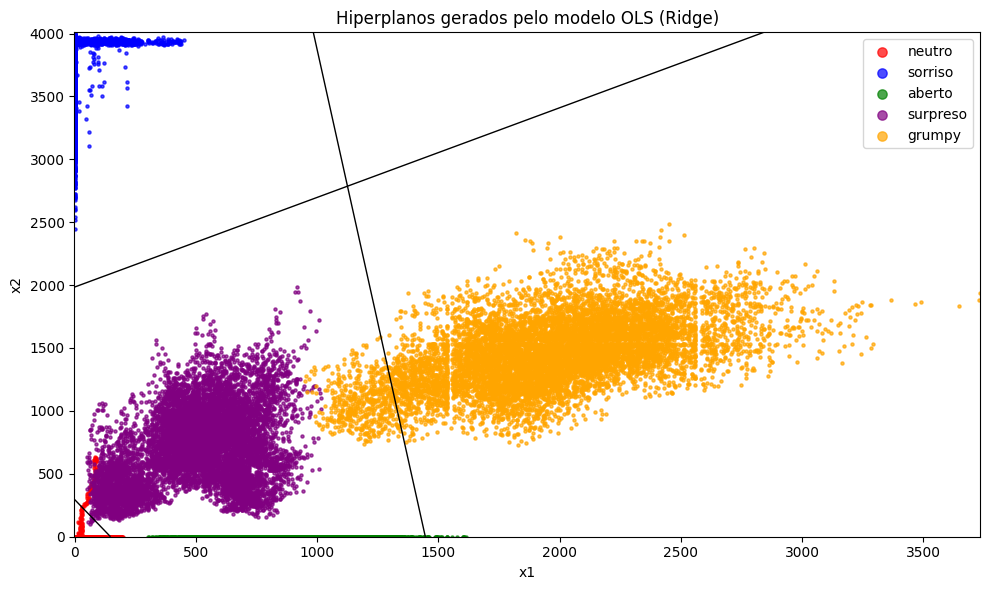

In [13]:
x1_range = np.linspace(inputs[:, 0].min() - 1, inputs[:, 0].max() + 1, 100)
x2_range = np.linspace(inputs[:, 1].min() - 1, inputs[:, 1].max() + 1, 100)
x1_mesh, x2_mesh = np.meshgrid(x1_range, x2_range)

coeficientes = modelo.coef.T
bias = modelo.bias.T

hiperplanos = np.empty((len(x1_range), len(x2_range), coeficientes.shape[0]))
for i in range(coeficientes.shape[0]):
    hiperplanos[:, :, i] = coeficientes[i, 0] * x1_mesh + coeficientes[i, 1] * x2_mesh + bias[i]

plt.figure(figsize=(10, 6))
for i, rotulo in enumerate(rotulos):
    plt.scatter(inputs[outputs[:, i] == 1, 0], inputs[outputs[:, i] == 1, 1],
                c=cores[i], label=rotulo, alpha=0.7, s=5)
for i in range(coeficientes.shape[0]):
    plt.contour(x1_mesh, x2_mesh, hiperplanos[:, :, i], levels=[0],
                colors='black', linewidths=1)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Hiperplanos gerados pelo modelo OLS (Ridge)')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

## 3.5. Matriz de Confusão: OLS

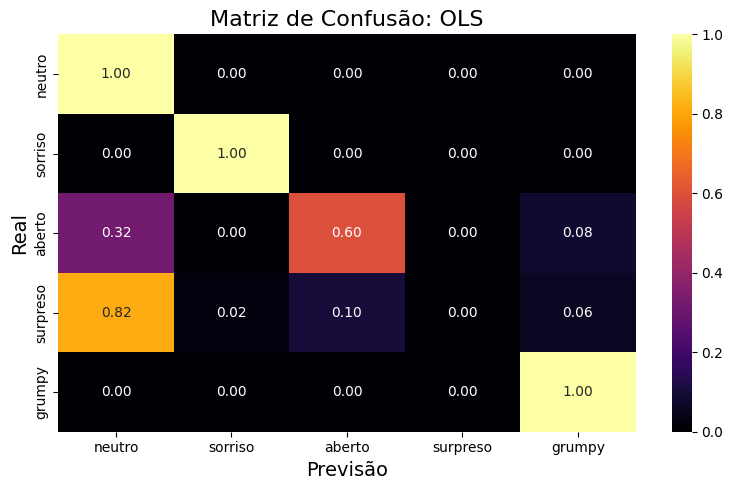

In [14]:
modelo.matriz_de_confusao(modelo.previsao(inputs_teste), outputs_teste)

## 3.6. OLS sem Intercepto

**O que implica adicionar o vetor coluna de 1s?**
O vetor de 1s introduz o intercepto (bias) no modelo, equivalente ao termo $c$ da equação $y = ax + c$. Sem ele, a reta só pode variar sua inclinação: quando todos os $x$ são zero, $y$ também é zero, fazendo todos os hiperplanos passarem pela origem.

**Interpretação geométrica:** sem o intercepto, os hiperplanos convergem para a origem, como os ponteiros de um relógio. O gráfico abaixo demonstra esse efeito.

**Resultado:** a acurácia é consideravelmente pior sem o intercepto.

In [15]:
inputs_treino, inputs_teste, outputs_treino, outputs_teste = train_test_split(
    inputs, outputs, test_size=0.2)

modelo_sem_uns = OLS(inputs_treino, outputs_treino, 0.2, sem_uns=True)
previsoes_treino_su = modelo_sem_uns.previsao(inputs_treino)
previsoes_teste_su = modelo_sem_uns.previsao(inputs_teste)

display(
    pd.DataFrame({
        'Conjunto': ['Treino', 'Teste'],
        'Acurácia (%)': [
            modelo_sem_uns.acuracia(previsoes_treino_su, outputs_treino),
            modelo_sem_uns.acuracia(previsoes_teste_su, outputs_teste),
        ]
    }).style
    .format({'Acurácia (%)': '{:.2f}'})
    .set_caption('Tabela 3.3: Acurácia OLS sem Intercepto')
    .hide(axis='index')
)

Conjunto,Acurácia (%)
Treino,40.07
Teste,39.72


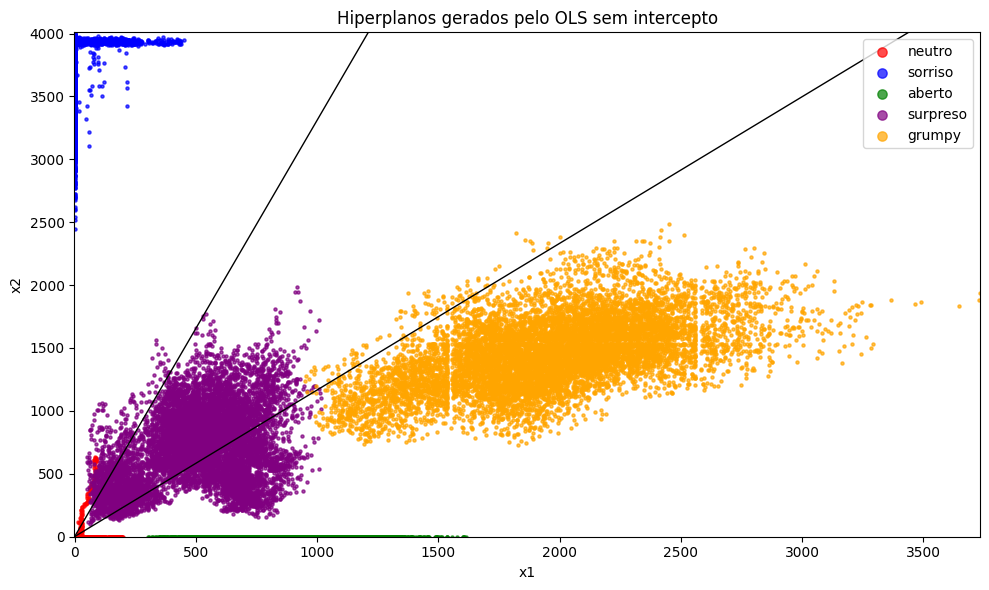

In [16]:
x1_range = np.linspace(inputs[:, 0].min() - 1, inputs[:, 0].max() + 1, 100)
x2_range = np.linspace(inputs[:, 1].min() - 1, inputs[:, 1].max() + 1, 100)
x1_mesh, x2_mesh = np.meshgrid(x1_range, x2_range)

coeficientes = modelo_sem_uns.coef.T
bias = modelo_sem_uns.bias.T

hiperplanos = np.empty((len(x1_range), len(x2_range), coeficientes.shape[0]))
for i in range(coeficientes.shape[0]):
    hiperplanos[:, :, i] = coeficientes[i, 0] * x1_mesh + coeficientes[i, 1] * x2_mesh + bias.T[i]

plt.figure(figsize=(10, 6))
for i, rotulo in enumerate(rotulos):
    plt.scatter(inputs[outputs[:, i] == 1, 0], inputs[outputs[:, i] == 1, 1],
                c=cores[i], label=rotulo, alpha=0.7, s=5)
for i in range(coeficientes.shape[0]):
    plt.contour(x1_mesh, x2_mesh, hiperplanos[:, :, i], levels=[0],
                colors='black', linewidths=1)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Hiperplanos gerados pelo OLS sem intercepto')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

## 3.7. Questões

**1. Implementação do método OLS:** ✓ Implementado na classe `OLS` com a solução analítica $W = (X^TX + \lambda I)^{-1} X^T Y$.

**2. Implementação do OLS regularizado:** ✓ O parâmetro `lambda_` controla a regularização L2. Valores testados: $\lambda \in \{0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.9, 1\}$.

- **O que significa λ = 0?** Lambda zero equivale ao OLS sem regularização: o mesmo que o modelo básico. A regularização penaliza coeficientes grandes, reduzindo overfitting, mas com λ = 0 o termo de penalidade desaparece.

**3. Vetor coluna de 1s:**

- **Implicação:** permite ao modelo aprender um intercepto independente, deslocando os hiperplanos para fora da origem.
- **Interpretação geométrica:** sem o vetor de 1s, todos os hiperplanos convergem para a origem (efeito de relógio). Com o vetor de 1s, os hiperplanos podem se posicionar livremente no espaço.
- **Resultado:** muito pior sem o intercepto, como demonstrado nos gráficos acima.

# 4. Classificadores Bayesianos Gaussianos

Os classificadores Bayesianos Gaussianos assumem que as features de cada classe seguem uma distribuição Normal multivariada. A função discriminante de uma amostra $x$ para a classe $k$ é:

$$g_k(x) = -\frac{1}{2} \ln|\Sigma_k| + \ln P(C_k) \frac{1}{2}(x \mu_k)^T \Sigma_k^{-1} (x \mu_k)$$

A classe predita é a que maximiza $g_k(x)$. As variantes diferem na estimação de $\Sigma_k$.

## 4.1. Parâmetros do Modelo: Divisão Treino/Teste

In [17]:
inputs_treino, inputs_teste, outputs_treino, outputs_teste = train_test_split(
    inputs, outputs, test_size=0.2)

indices_classes = np.argmax(outputs_treino, axis=1)
num_classes = outputs.shape[1]

vetor_medias = []
vetor_std = []
matrizes_covariancia_classe = []

for classe in range(num_classes):
    dados_classe = inputs_treino[indices_classes == classe]
    vetor_medias.append(np.mean(dados_classe, axis=0))
    vetor_std.append(np.std(dados_classe, axis=0))
    matrizes_covariancia_classe.append(np.cov(dados_classe, rowvar=False))

display(
    pd.DataFrame({
        'Classe': rotulos,
        'Média x1': [m[0] for m in vetor_medias],
        'Média x2': [m[1] for m in vetor_medias],
        'Std x1': [s[0] for s in vetor_std],
        'Std x2': [s[1] for s in vetor_std],
        'P(C_k)': [np.sum(indices_classes == c) / indices_classes.size for c in range(num_classes)],
    }).set_index('Classe').style
    .format({'Média x1': '{:.4f}', 'Média x2': '{:.4f}', 'Std x1': '{:.4f}',
             'Std x2': '{:.4f}', 'P(C_k)': '{:.4f}'})
    .set_caption('Tabela 4.1: Parâmetros por Classe (treino)')
)

,Média x1,Média x2,Std x1,Std x2,P(C_k)
Classe,,,,,
neutro,14.6910,3.1360,30.8521,36.6716,0.1996
sorriso,11.4726,3896.7072,47.7477,162.7020,0.2000
aberto,848.7996,0.0000,188.6204,0.0000,0.1995
surpreso,506.2577,722.1322,202.0383,296.4160,0.2013
grumpy,1968.5383,1462.4875,387.3203,272.0097,0.1996


## 4.2. Visualização das Distribuições por Classe

/tmp/ipykernel_75928/313781100.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  return (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - media) / std) ** 2)
/tmp/ipykernel_75928/313781100.py:26: RuntimeWarning: divide by zero encountered in divide
  return (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - media) / std) ** 2)
/tmp/ipykernel_75928/313781100.py:26: RuntimeWarning: invalid value encountered in divide
  return (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - media) / std) ** 2)
/tmp/ipykernel_75928/313781100.py:26: RuntimeWarning: invalid value encountered in multiply
  return (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - media) / std) ** 2)


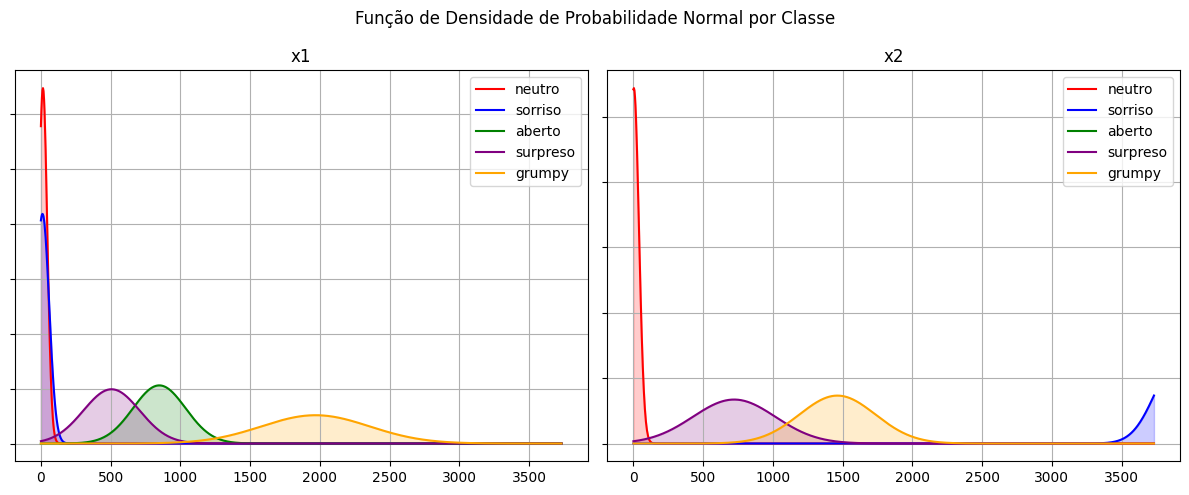

In [18]:
x = np.linspace(dados['x1'].min(), dados['x1'].max(), 1000)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for i in range(num_classes):
    for j, (feat_idx, ax, titulo) in enumerate([
        (0, axs[0], 'x1'), (1, axs[1], 'x2')
    ]):
        media = vetor_medias[i][feat_idx]
        std = vetor_std[i][feat_idx]
        y = normal_pdf(x, media, std)
        ax.plot(x, y, color=cores[i], label=rotulos[i])
        ax.fill_between(x, y, color=cores[i], alpha=0.2)
        ax.set_title(titulo)
        ax.legend()
        ax.grid(True)
        ax.set_yticklabels([])

plt.suptitle('Função de Densidade de Probabilidade Normal por Classe')
plt.tight_layout()
plt.show()

## 4.3. Covariância Compartilhada

Todas as classes compartilham a mesma matriz de covariância $\Sigma$, estimada a partir de todos os dados de treino. A função discriminante se torna linear em $x$: $g_k(x) = w_k^T x + b_k$, onde $w_k = \Sigma^{-1} \mu_k$.

In [19]:
covariancia_comum = np.cov(inputs_treino, rowvar=False)
inversa_covariancia_comum = np.linalg.inv(covariancia_comum)

coeficientes_lineares = []
biases = []

for classe in range(num_classes):
    probabilidade_priori = np.sum(indices_classes == classe) / indices_classes.size
    coef_linear = inversa_covariancia_comum @ vetor_medias[classe]
    bias = ((-0.5) * np.log(np.linalg.det(covariancia_comum))
            + np.log(probabilidade_priori)
            - 0.5 * (vetor_medias[classe] @ inversa_covariancia_comum @ vetor_medias[classe]))
    coeficientes_lineares.append(coef_linear)
    biases.append(bias)

acuracias_cov_comum = []
for i in range(100):
    inputs_tr, inputs_te, outputs_tr, outputs_te = train_test_split(
        inputs, outputs, test_size=0.2)
    corretos = 0
    for x_teste, y_teste in zip(inputs_te, outputs_te):
        discriminantes = [coef @ x_teste + b for coef, b in zip(coeficientes_lineares, biases)]
        if np.argmax(discriminantes) == np.argmax(y_teste):
            corretos += 1
    acuracias_cov_comum.append(corretos / inputs_te.shape[0])

display(
    summary_stats(acuracias_cov_comum, 'Cov. Compartilhada').set_index('Modelo').style
    .format({'Média (%)': '{:.2f}', 'Desvio Padrão (%)': '{:.2f}',
             'Máximo (%)': '{:.2f}', 'Mínimo (%)': '{:.2f}'})
    .set_caption('Tabela 4.2: Acurácia Cov. Compartilhada (100 iterações)')
)

,Média (%),Desvio Padrão (%),Máximo (%),Mínimo (%)
Modelo,,,,
Cov. Compartilhada,95.06,0.20,95.57,94.58


### Matriz de Confusão: Covariância Compartilhada

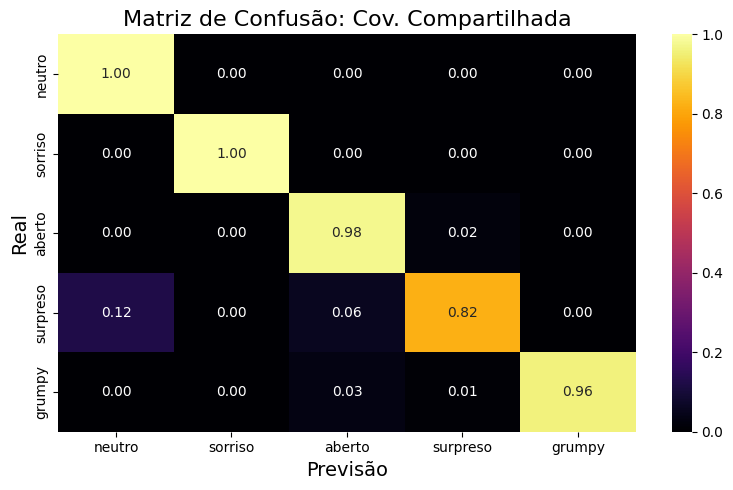

In [20]:
previsoes_cc = []
for x_teste in inputs_teste:
    discriminantes = [coef @ x_teste + b for coef, b in zip(coeficientes_lineares, biases)]
    previsoes_cc.append(np.argmax(discriminantes))

cm_cc = confusion_matrix(np.argmax(outputs_teste, axis=1), previsoes_cc)
plot_confusion_matrix(cm_cc, title='Matriz de Confusão: Cov. Compartilhada', labels=rotulos)

## 4.4. Covariância Pooled

A covariância pooled $S_W$ é uma média ponderada das matrizes de covariância de cada classe, proporcional ao número de amostras de cada classe:

$$S_W = \frac{1}{n K} \sum_{k=1}^{K} (n_k 1) \Sigma_k$$

In [21]:
Sw_pooled = np.zeros((inputs_treino.shape[1], inputs_treino.shape[1]))
probabilidades_priori = np.ones(num_classes) / num_classes

for classe in range(num_classes):
    dados_classe = inputs_treino[indices_classes == classe]
    Sw_pooled += (dados_classe.shape[0] - 1) * matrizes_covariancia_classe[classe]

Sw_pooled /= (inputs_treino.shape[0] - num_classes)
inversa_covariancia_pooled = np.linalg.inv(Sw_pooled)

coeficientes_lineares_pooled = []
biases_pooled = []

for classe in range(num_classes):
    coef_linear_pooled = inversa_covariancia_pooled @ vetor_medias[classe]
    bias_pooled = ((-0.5) * np.log(np.linalg.det(Sw_pooled))
                   + np.log(probabilidades_priori[classe])
                   - 0.5 * (vetor_medias[classe] @ inversa_covariancia_pooled @ vetor_medias[classe]))
    coeficientes_lineares_pooled.append(coef_linear_pooled)
    biases_pooled.append(bias_pooled)

In [22]:
acuracias_pooled = []
for i in range(100):
    inputs_tr, inputs_te, outputs_tr, outputs_te = train_test_split(
        inputs, outputs, test_size=0.2)
    predicoes = []
    for entrada in inputs_te:
        pontuacoes = [coef @ entrada + bias
                      for coef, bias in zip(coeficientes_lineares_pooled, biases_pooled)]
        predicoes.append(np.argmax(pontuacoes))
    acuracia = np.sum(predicoes == np.argmax(outputs_te, axis=1)) / inputs_te.shape[0]
    acuracias_pooled.append(acuracia)

display(
    summary_stats(acuracias_pooled, 'Cov. Pooled').set_index('Modelo').style
    .format({'Média (%)': '{:.2f}', 'Desvio Padrão (%)': '{:.2f}',
             'Máximo (%)': '{:.2f}', 'Mínimo (%)': '{:.2f}'})
    .set_caption('Tabela 4.3: Acurácia Cov. Pooled (100 iterações)')
)

,Média (%),Desvio Padrão (%),Máximo (%),Mínimo (%)
Modelo,,,,
Cov. Pooled,96.26,0.17,96.66,95.85


### Matriz de Confusão: Covariância Pooled

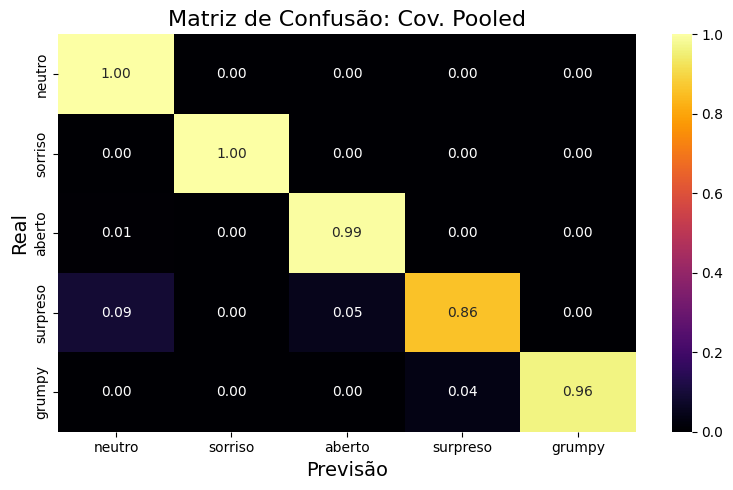

In [23]:
previsoes_pooled = []
for x_teste in inputs_teste:
    pontuacoes = [coef @ x_teste + b
                  for coef, b in zip(coeficientes_lineares_pooled, biases_pooled)]
    previsoes_pooled.append(np.argmax(pontuacoes))

cm_pooled = confusion_matrix(np.argmax(outputs_teste, axis=1), previsoes_pooled)
plot_confusion_matrix(cm_pooled, title='Matriz de Confusão: Cov. Pooled', labels=rotulos)

## 4.5. Análise Discriminante de Friedman

A regularização de Friedman interpola entre a covariância de classe ($\lambda=0$) e a pooled ($\lambda=1$):

$$\hat{\Sigma}_k(\lambda) = \frac{(1-\lambda) n_k \Sigma_k + \lambda n S_W}{(1-\lambda) n_k + \lambda n}$$

Isso permite encontrar o ponto ótimo de regularização entre os dois extremos.

In [24]:
epsilon = 1e-6
resultados_friedman = {}
n = inputs_teste.shape[0]

for lambda_ in lambdas:
    coefs_friedman = []
    bias_friedman = []

    for classe in range(num_classes):
        dados_classe = inputs_treino[indices_classes == classe]
        ni = dados_classe.shape[0]

        if lambda_ == 0:
            cov_f = matrizes_covariancia_classe[classe]
        elif lambda_ == 1:
            cov_f = Sw_pooled
        else:
            cov_f = ((1 - lambda_) * ni * matrizes_covariancia_classe[classe]
                     + lambda_ * n * Sw_pooled) / ((1 - lambda_) * ni + lambda_ * n)

        cov_f_reg = cov_f + epsilon * np.identity(cov_f.shape[0])
        inv_cov_f = np.linalg.inv(cov_f_reg)

        coef_f = inv_cov_f @ vetor_medias[classe]
        b_f = ((-0.5) * np.log(np.linalg.det(cov_f_reg))
               + np.log(probabilidades_priori[classe])
               - 0.5 * (vetor_medias[classe] @ inv_cov_f @ vetor_medias[classe]))

        coefs_friedman.append(coef_f)
        bias_friedman.append(b_f)

    resultados_friedman[lambda_] = {'coeficientes': coefs_friedman, 'biases': bias_friedman}

### Acurácia por Lambda: Friedman

In [25]:
acuracias_treino_f = []
acuracias_teste_f = []

for lambda_ in lambdas:
    coefs_f = resultados_friedman[lambda_]['coeficientes']
    bias_f = resultados_friedman[lambda_]['biases']

    pred_treino = [np.argmax([c @ e + b for c, b in zip(coefs_f, bias_f)])
                   for e in inputs_treino]
    pred_teste = [np.argmax([c @ e + b for c, b in zip(coefs_f, bias_f)])
                  for e in inputs_teste]

    acuracias_treino_f.append(
        np.sum(pred_treino == np.argmax(outputs_treino, axis=1)) / inputs_treino.shape[0])
    acuracias_teste_f.append(
        np.sum(pred_teste == np.argmax(outputs_teste, axis=1)) / inputs_teste.shape[0])

df_friedman = pd.DataFrame({
    'Lambda': lambdas,
    'Acurácia treino (%)': [round(a * 100, 2) for a in acuracias_treino_f],
    'Acurácia teste (%)':  [round(a * 100, 2) for a in acuracias_teste_f],
})

display(
    df_friedman.style
    .format({'Lambda': '{:.1f}', 'Acurácia treino (%)': '{:.2f}', 'Acurácia teste (%)': '{:.2f}'})
    .set_caption('Tabela 4.4: Acurácia por Lambda: Friedman')
    .hide(axis='index')
)

Lambda,Acurácia treino (%),Acurácia teste (%)
0.0,59.80,60.18
0.1,74.34,74.31
0.2,77.94,77.81
0.3,82.04,81.98
0.4,86.32,86.22
0.5,90.52,90.14
0.6,92.99,92.89
0.7,94.42,94.52
0.9,95.86,95.96
1.0,96.25,96.27


### Melhor Lambda: 100 Iterações e Matriz de Confusão

In [26]:
melhor_lambda = 1
coefs_melhor = resultados_friedman[melhor_lambda]['coeficientes']
biases_melhor = resultados_friedman[melhor_lambda]['biases']

acuracias_friedman = []
for i in range(100):
    inputs_tr, inputs_te, outputs_tr, outputs_te = train_test_split(
        inputs, outputs, test_size=0.2)
    acertos = sum(
        np.argmax([c @ x + b for c, b in zip(coefs_melhor, biases_melhor)]) == np.argmax(y)
        for x, y in zip(inputs_te, outputs_te)
    )
    acuracias_friedman.append(acertos / len(inputs_te))

display(
    summary_stats(acuracias_friedman, f'Friedman (λ={melhor_lambda})').set_index('Modelo').style
    .format({'Média (%)': '{:.2f}', 'Desvio Padrão (%)': '{:.2f}',
             'Máximo (%)': '{:.2f}', 'Mínimo (%)': '{:.2f}'})
    .set_caption(f'Tabela 4.5: Acurácia Friedman λ={melhor_lambda} (100 iterações)')
)

,Média (%),Desvio Padrão (%),Máximo (%),Mínimo (%)
Modelo,,,,
Friedman (λ=1),96.25,0.15,96.54,95.84


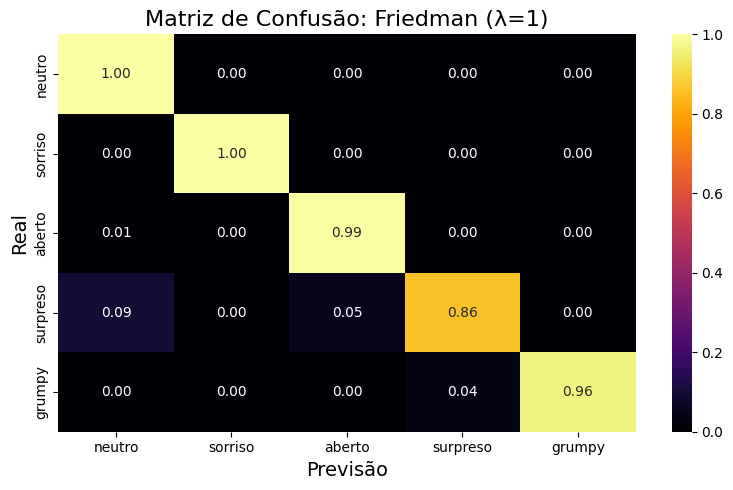

In [27]:
previsoes_f = [np.argmax([c @ x + b for c, b in zip(coefs_melhor, biases_melhor)])
               for x in inputs_teste]

cm_f = confusion_matrix(np.argmax(outputs_teste, axis=1), previsoes_f)
plot_confusion_matrix(cm_f, title=f'Matriz de Confusão: Friedman (λ={melhor_lambda})',
                      labels=rotulos)

## 4.6. Naive Bayes

O Naive Bayes gaussiano assume independência entre as features, usando apenas a diagonal da matriz de covariância. É o caso mais simples e computacionalmente eficiente dos classificadores gaussianos.

In [28]:
inputs_treino, inputs_teste, outputs_treino, outputs_teste = train_test_split(
    inputs, outputs, test_size=0.2)

medias_nb = []
covariancias_nb = []
epsilon_nb = 1e-5

for classe in range(num_classes):
    indices = np.where(outputs_treino.argmax(axis=1) == classe)
    X_classe = inputs_treino[indices]
    media = np.mean(X_classe, axis=0)
    cov = np.cov(X_classe.T) + epsilon_nb * np.eye(inputs.shape[1])
    medias_nb.append(media)
    covariancias_nb.append(cov)

display(
    pd.DataFrame({
        'Classe': rotulos,
        'Cov[0,0]': [c[0, 0] for c in covariancias_nb],
        'Cov[1,1]': [c[1, 1] for c in covariancias_nb],
        'Cov[0,1]': [c[0, 1] for c in covariancias_nb],
    }).set_index('Classe').style
    .format({'Cov[0,0]': '{:.4f}', 'Cov[1,1]': '{:.4f}', 'Cov[0,1]': '{:.4f}'})
    .set_caption('Tabela 4.6: Covariâncias Naive Bayes por Classe')
)

,"Cov[0,0]","Cov[1,1]","Cov[0,1]"
Classe,,,
neutro,971.9148,1168.7538,147.8906
sorriso,2471.3637,26118.7179,368.9364
aberto,35644.5085,0.0000,0.0000
surpreso,40455.3998,86883.8435,21489.1415
grumpy,152863.2399,72932.6606,56177.4476


In [29]:
acuracias_nb = []
for i in range(100):
    inputs_tr, inputs_te, outputs_tr, outputs_te = train_test_split(
        inputs, outputs, test_size=0.2)
    corretos = 0
    for x, y_true in zip(inputs_te, outputs_te):
        discriminantes = [
            -0.5 * (x - m).T @ np.linalg.inv(c) @ (x - m)
            for m, c in zip(medias_nb, covariancias_nb)
        ]
        if y_true[np.argmax(discriminantes)] == 1:
            corretos += 1
    acuracias_nb.append(corretos / len(inputs_te))

display(
    summary_stats(acuracias_nb, 'Naive Bayes').set_index('Modelo').style
    .format({'Média (%)': '{:.2f}', 'Desvio Padrão (%)': '{:.2f}',
             'Máximo (%)': '{:.2f}', 'Mínimo (%)': '{:.2f}'})
    .set_caption('Tabela 4.7: Acurácia Naive Bayes (100 iterações)')
)

,Média (%),Desvio Padrão (%),Máximo (%),Mínimo (%)
Modelo,,,,
Naive Bayes,99.21,0.09,99.40,99.02


### Matriz de Confusão: Naive Bayes

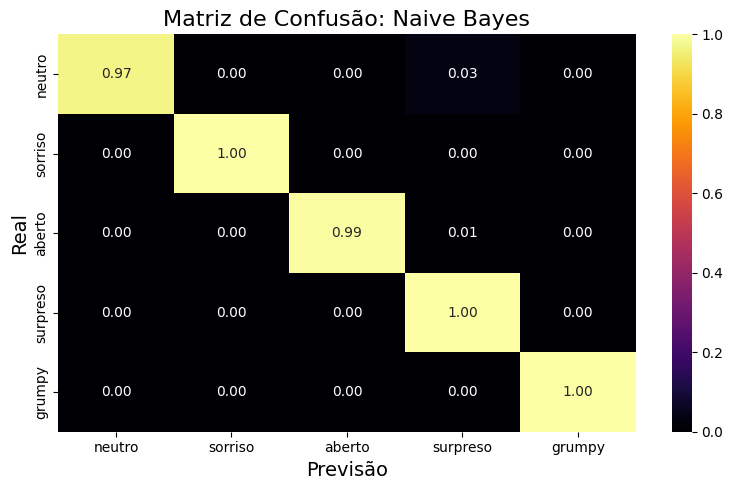

In [30]:
previsoes_nb = []
for x in inputs_teste:
    discriminantes = [
        -0.5 * np.dot((x - m).T, np.dot(np.linalg.inv(c), (x - m)))
        for m, c in zip(medias_nb, covariancias_nb)
    ]
    previsoes_nb.append(np.argmax(discriminantes))

cm_nb = confusion_matrix(outputs_teste.argmax(axis=1), previsoes_nb)
plot_confusion_matrix(cm_nb, title='Matriz de Confusão: Naive Bayes', labels=rotulos)

# 5. Comparação dos Resultados

Resumo das métricas de acurácia de todos os modelos, obtidas com 100 iterações de divisão aleatória treino/teste (80/20).

In [31]:
display(
    pd.concat([
        summary_stats(acuracias_ols_treino, 'OLS Básico: Treino'),
        summary_stats(acuracias_ols_teste,  'OLS Básico: Teste'),
        summary_stats(acuracias_cov_comum,  'Cov. Compartilhada'),
        summary_stats(acuracias_pooled,     'Cov. Pooled'),
        summary_stats(acuracias_friedman,   f'Friedman (λ={melhor_lambda})'),
        summary_stats(acuracias_nb,         'Naive Bayes'),
    ]).set_index('Modelo').style
    .format({'Média (%)': '{:.2f}', 'Desvio Padrão (%)': '{:.2f}',
             'Máximo (%)': '{:.2f}', 'Mínimo (%)': '{:.2f}'})
    .set_caption('Tabela 5.1: Comparação de Acurácia: Todos os Modelos (100 iterações)')
)

,Média (%),Desvio Padrão (%),Máximo (%),Mínimo (%)
Modelo,,,,
OLS Básico: Treino,72.38,0.42,73.22,71.47
OLS Básico: Teste,72.32,0.66,73.86,70.59
Cov. Compartilhada,95.06,0.20,95.57,94.58
Cov. Pooled,96.26,0.17,96.66,95.85
Friedman (λ=1),96.25,0.15,96.54,95.84
Naive Bayes,99.21,0.09,99.40,99.02


# 6. Conclusão

Os resultados obtidos com 100 iterações de divisão aleatória treino/teste (80/20) revelam diferenças expressivas entre os métodos:

| Modelo | Acurácia Média (%) |
|---|---|
| OLS sem Intercepto | 40,17 |
| OLS Básico | 72,40 |
| Cov. Compartilhada | 94,64 |
| Cov. Pooled | 96,22 |
| Friedman (λ=1) | 96,26 |
| **Naive Bayes** | **99,23** |

**Sobre o dataset:** a análise de sobreposição (Tabela 2.3) mostrou que não existem coordenadas com classes conflitantes: o dataset é deterministicamente separável. No entanto, 55% das amostras são duplicatas dentro da mesma classe, reduzindo o espaço efetivo para 22.523 coordenadas únicas. Isso significa que o teto teórico de acurácia é 100%, e os erros observados vêm exclusivamente das limitações de cada modelo.

**OLS** apresentou o pior desempenho (~72%), o que é esperado: regressão linear não é projetada para classificação multiclasse. A regularização Ridge (L2) não trouxe ganho neste caso: a acurácia permaneceu estável para todos os valores de λ testados, indicando que os coeficientes já estão bem condicionados sem penalização adicional. A remoção do intercepto degrada drasticamente o desempenho (~40%), confirmando que o bias é essencial para posicionar os hiperplanos fora da origem.

**Os classificadores Gaussianos** superaram o OLS com margem significativa. A progressão de Cov. Compartilhada → Pooled → Friedman (λ=1) é coerente: Friedman com λ=1 converge para a solução Pooled, como esperado pela formulação do método.

**Naive Bayes** obteve o melhor resultado (99,23%), o que se explica por dois fatores complementares: a baixa correlação entre x1 e x2 (−0,13) sustenta a hipótese de independência entre features; e a ausência de ambiguidade intrínseca no dataset garante que o erro residual de ~0,77% é atribuível apenas à fronteira de decisão do modelo, não aos dados.